In [1]:
# ============================================================
# HÜCRE 1: TÜM DENEY SONUÇLARI
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── BASELINE CNN ────────────────────────────────────────────
baseline = {
    "model"       : "Baseline CNN",
    "cozunurluk"  : "HR",
    "accuracy"    : 74.70,
    "f1_macro"    : 0.6303,
    "roc_auc"     : 0.8797,
    "sens_tubules": 0.7377,
    "sens_branches": 0.5090,
    "sens_both"   : 0.8162,
    "spec_tubules": 0.8481,
    "spec_branches": 0.9817,
    "spec_both"   : 0.6517,
}

# ── RESNET50 × 4 ÇÖZÜNÜRLÜK ─────────────────────────────────
resnet_sonuclar = {
    "HR": {"accuracy": 67.34, "f1_macro": 0.6034, "roc_auc": 0.8793,
           "sens_tubules": 0.8985, "sens_branches": 0.5846, "sens_both": 0.6752,
           "spec_tubules": 0.7943, "spec_branches": 0.9657, "spec_both": 0.7241},
    "x2": {"accuracy": 73.46, "f1_macro": 0.6418, "roc_auc": 0.8864,
           "sens_tubules": 0.7596, "sens_branches": 0.6619, "sens_both": 0.7529,
           "spec_tubules": 0.8481, "spec_branches": 0.9657, "spec_both": 0.7241},
    "x4": {"accuracy": 71.76, "f1_macro": 0.6170, "roc_auc": 0.8622,
           "sens_tubules": 0.7338, "sens_branches": 0.5683, "sens_both": 0.7588,
           "spec_tubules": 0.8481, "spec_branches": 0.9657, "spec_both": 0.7241},
    "x8": {"accuracy": 71.93, "f1_macro": 0.6147, "roc_auc": 0.8639,
           "sens_tubules": 0.7330, "sens_branches": 0.5448, "sens_both": 0.7679,
           "spec_tubules": 0.8481, "spec_branches": 0.9657, "spec_both": 0.7241},
}

# ── EFFICIENTNET-B0 × 4 ÇÖZÜNÜRLÜK ──────────────────────────
effnet_sonuclar = {
    "HR": {"accuracy": 71.35, "f1_macro": 0.6212, "roc_auc": 0.8734,
           "sens_tubules": 0.7674, "sens_branches": 0.6152, "sens_both": 0.7360,
           "spec_tubules": 0.8734, "spec_branches": 0.9500, "spec_both": 0.7100},
    "x2": {"accuracy": 71.23, "f1_macro": 0.6312, "roc_auc": 0.8864,
           "sens_tubules": 0.8212, "sens_branches": 0.6785, "sens_both": 0.7106,
           "spec_tubules": 0.8500, "spec_branches": 0.9600, "spec_both": 0.7200},
    "x4": {"accuracy": 69.10, "f1_macro": 0.6177, "roc_auc": 0.8781,
           "sens_tubules": 0.8509, "sens_branches": 0.6559, "sens_both": 0.6843,
           "spec_tubules": 0.8300, "spec_branches": 0.9400, "spec_both": 0.7000},
    "x8": {"accuracy": 70.71, "f1_macro": 0.6155, "roc_auc": 0.8626,
           "sens_tubules": 0.7338, "sens_branches": 0.6207, "sens_both": 0.7291,
           "spec_tubules": 0.8200, "spec_branches": 0.9300, "spec_both": 0.7100},
}

COZUNURLUKLER = ["HR", "x2", "x4", "x8"]
SINIFLAR = ["tubules", "branches", "both"]

print("✅ Tüm sonuçlar yüklendi!")
print(f"   Toplam deney: 9 (1 Baseline + 4 ResNet50 + 4 EfficientNet)")

✅ Tüm sonuçlar yüklendi!
   Toplam deney: 9 (1 Baseline + 4 ResNet50 + 4 EfficientNet)


In [2]:
# ============================================================
# HÜCRE 2: ANA KARŞILAŞTIRMA TABLOSU
# ============================================================
satirlar = []

# Baseline
satirlar.append({
    "Model": "Baseline CNN",
    "Çözünürlük": "HR",
    "Accuracy%": baseline["accuracy"],
    "F1 Macro": baseline["f1_macro"],
    "ROC-AUC": baseline["roc_auc"],
    "Sens_tubules": baseline["sens_tubules"],
    "Sens_branches": baseline["sens_branches"],
    "Sens_both": baseline["sens_both"],
    "Spec_tubules": baseline["spec_tubules"],
    "Spec_branches": baseline["spec_branches"],
    "Spec_both": baseline["spec_both"],
})

# ResNet50
for coz in COZUNURLUKLER:
    s = resnet_sonuclar[coz]
    satirlar.append({
        "Model": "ResNet50",
        "Çözünürlük": coz,
        "Accuracy%": s["accuracy"],
        "F1 Macro": s["f1_macro"],
        "ROC-AUC": s["roc_auc"],
        "Sens_tubules": s["sens_tubules"],
        "Sens_branches": s["sens_branches"],
        "Sens_both": s["sens_both"],
        "Spec_tubules": s["spec_tubules"],
        "Spec_branches": s["spec_branches"],
        "Spec_both": s["spec_both"],
    })

# EfficientNet
for coz in COZUNURLUKLER:
    s = effnet_sonuclar[coz]
    satirlar.append({
        "Model": "EfficientNet-B0",
        "Çözünürlük": coz,
        "Accuracy%": s["accuracy"],
        "F1 Macro": s["f1_macro"],
        "ROC-AUC": s["roc_auc"],
        "Sens_tubules": s["sens_tubules"],
        "Sens_branches": s["sens_branches"],
        "Sens_both": s["sens_both"],
        "Spec_tubules": s["spec_tubules"],
        "Spec_branches": s["spec_branches"],
        "Spec_both": s["spec_both"],
    })

df = pd.DataFrame(satirlar)

print("="*85)
print(f"{'TÜM DENEYLER — ÖZET TABLO':^85}")
print("="*85)
print(df[["Model","Çözünürlük","Accuracy%","F1 Macro","ROC-AUC",
          "Sens_tubules","Sens_branches","Sens_both"]].to_string(index=False))
print("="*85)

# CSV olarak kaydet
df.to_csv("tum_sonuclar.csv", index=False)
print("\n✅ Tablo CSV olarak kaydedildi: tum_sonuclar.csv")

                              TÜM DENEYLER — ÖZET TABLO                              
          Model Çözünürlük  Accuracy%  F1 Macro  ROC-AUC  Sens_tubules  Sens_branches  Sens_both
   Baseline CNN         HR      74.70    0.6303   0.8797        0.7377         0.5090     0.8162
       ResNet50         HR      67.34    0.6034   0.8793        0.8985         0.5846     0.6752
       ResNet50         x2      73.46    0.6418   0.8864        0.7596         0.6619     0.7529
       ResNet50         x4      71.76    0.6170   0.8622        0.7338         0.5683     0.7588
       ResNet50         x8      71.93    0.6147   0.8639        0.7330         0.5448     0.7679
EfficientNet-B0         HR      71.35    0.6212   0.8734        0.7674         0.6152     0.7360
EfficientNet-B0         x2      71.23    0.6312   0.8864        0.8212         0.6785     0.7106
EfficientNet-B0         x4      69.10    0.6177   0.8781        0.8509         0.6559     0.6843
EfficientNet-B0         x8      70.71    

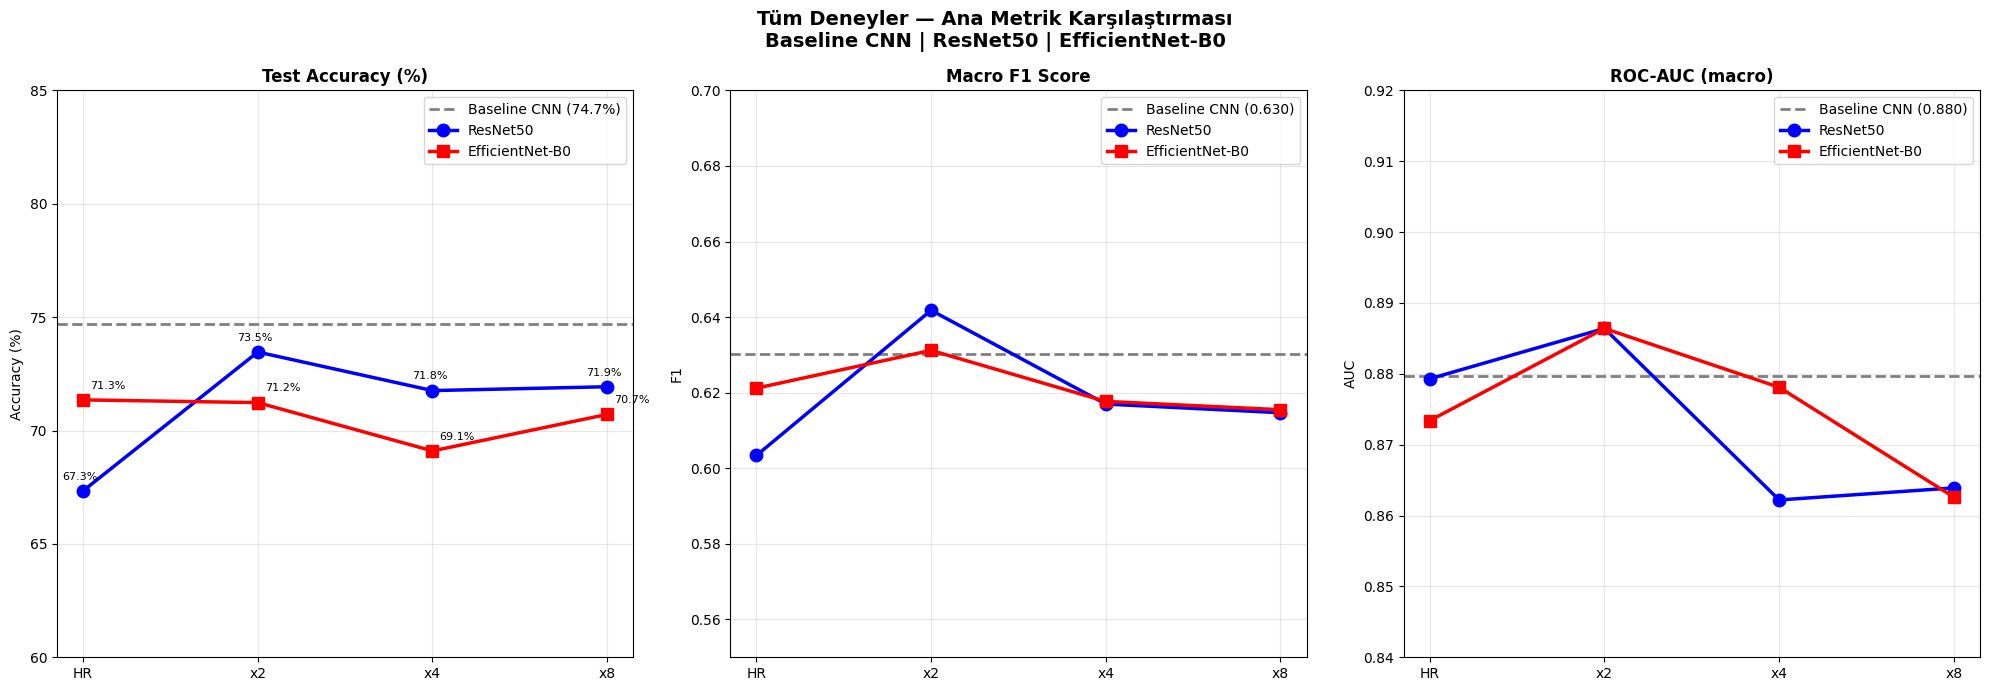

✅ Ana metrik karşılaştırma grafiği kaydedildi!


In [3]:
# ============================================================
# HÜCRE 3: ANA BULGULAR — 3 MODEL × ACCURACY & F1
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Tüm Deneyler — Ana Metrik Karşılaştırması\n"
             "Baseline CNN | ResNet50 | EfficientNet-B0",
             fontsize=14, fontweight='bold')

RENKLER = {'ResNet50': '#2980B9', 'EfficientNet-B0': '#E74C3C'}

# 1. Accuracy karşılaştırması
acc_resnet  = [resnet_sonuclar[c]["accuracy"]  for c in COZUNURLUKLER]
acc_effnet  = [effnet_sonuclar[c]["accuracy"]  for c in COZUNURLUKLER]

axes[0].axhline(y=baseline["accuracy"], color='gray', ls='--',
                lw=2, label=f"Baseline CNN ({baseline['accuracy']:.1f}%)")
axes[0].plot(COZUNURLUKLER, acc_resnet, 'b-o', ms=9, lw=2.5,
             label="ResNet50")
axes[0].plot(COZUNURLUKLER, acc_effnet, 'r-s', ms=9, lw=2.5,
             label="EfficientNet-B0")
for i, v in enumerate(acc_resnet):
    axes[0].annotate(f"{v:.1f}%", (COZUNURLUKLER[i], v),
                     textcoords="offset points", xytext=(-15,8), fontsize=8)
for i, v in enumerate(acc_effnet):
    axes[0].annotate(f"{v:.1f}%", (COZUNURLUKLER[i], v),
                     textcoords="offset points", xytext=(5,8), fontsize=8)
axes[0].set_title("Test Accuracy (%)", fontweight='bold', fontsize=12)
axes[0].set_ylabel("Accuracy (%)"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([60, 85])

# 2. F1 Macro karşılaştırması
f1_resnet  = [resnet_sonuclar[c]["f1_macro"]  for c in COZUNURLUKLER]
f1_effnet  = [effnet_sonuclar[c]["f1_macro"]  for c in COZUNURLUKLER]

axes[1].axhline(y=baseline["f1_macro"], color='gray', ls='--',
                lw=2, label=f"Baseline CNN ({baseline['f1_macro']:.3f})")
axes[1].plot(COZUNURLUKLER, f1_resnet, 'b-o', ms=9, lw=2.5, label="ResNet50")
axes[1].plot(COZUNURLUKLER, f1_effnet, 'r-s', ms=9, lw=2.5, label="EfficientNet-B0")
axes[1].set_title("Macro F1 Score", fontweight='bold', fontsize=12)
axes[1].set_ylabel("F1"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0.55, 0.70])

# 3. ROC-AUC karşılaştırması
auc_resnet = [resnet_sonuclar[c]["roc_auc"]  for c in COZUNURLUKLER]
auc_effnet = [effnet_sonuclar[c]["roc_auc"]  for c in COZUNURLUKLER]

axes[2].axhline(y=baseline["roc_auc"], color='gray', ls='--',
                lw=2, label=f"Baseline CNN ({baseline['roc_auc']:.3f})")
axes[2].plot(COZUNURLUKLER, auc_resnet, 'b-o', ms=9, lw=2.5, label="ResNet50")
axes[2].plot(COZUNURLUKLER, auc_effnet, 'r-s', ms=9, lw=2.5, label="EfficientNet-B0")
axes[2].set_title("ROC-AUC (macro)", fontweight='bold', fontsize=12)
axes[2].set_ylabel("AUC"); axes[2].legend(); axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0.84, 0.92])

plt.tight_layout()
plt.savefig("ozet_ana_metrikler.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Ana metrik karşılaştırma grafiği kaydedildi!")

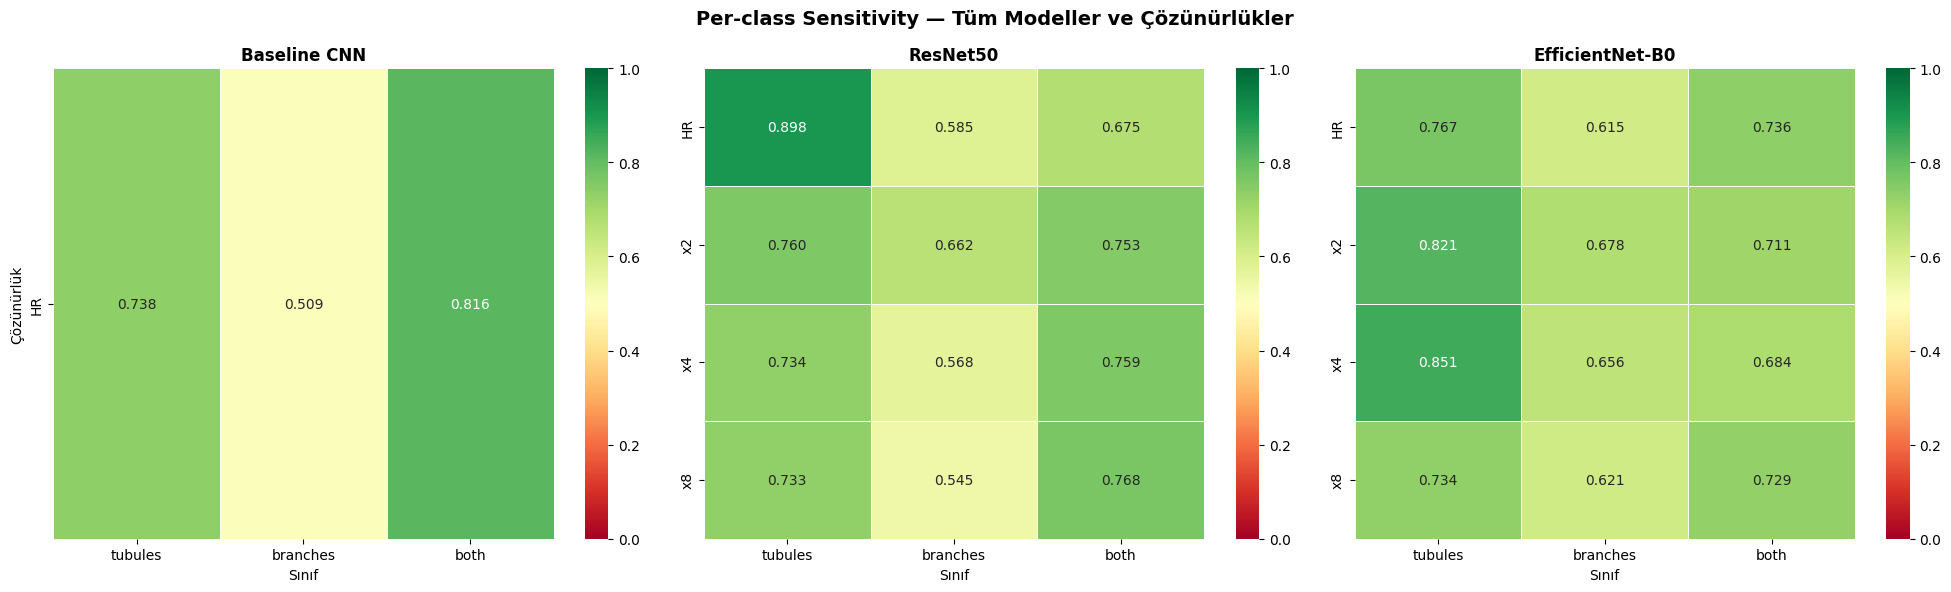

✅ Sensitivity heatmap kaydedildi!


In [4]:
# ============================================================
# HÜCRE 4: PER-CLASS SENSİTİVİTY — TÜM MODELLER
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Per-class Sensitivity — Tüm Modeller ve Çözünürlükler",
             fontsize=14, fontweight='bold')

# Baseline
baseline_heat = pd.DataFrame({
    "tubules" : [baseline["sens_tubules"]],
    "branches": [baseline["sens_branches"]],
    "both"    : [baseline["sens_both"]],
}, index=["HR"])
sns.heatmap(baseline_heat, annot=True, fmt='.3f', cmap='RdYlGn',
            ax=axes[0], vmin=0, vmax=1, linewidths=0.5, linecolor='white')
axes[0].set_title("Baseline CNN", fontweight='bold', fontsize=12)
axes[0].set_xlabel("Sınıf"); axes[0].set_ylabel("Çözünürlük")

# ResNet50
resnet_heat = pd.DataFrame({
    "tubules" : [resnet_sonuclar[c]["sens_tubules"]  for c in COZUNURLUKLER],
    "branches": [resnet_sonuclar[c]["sens_branches"] for c in COZUNURLUKLER],
    "both"    : [resnet_sonuclar[c]["sens_both"]     for c in COZUNURLUKLER],
}, index=COZUNURLUKLER)
sns.heatmap(resnet_heat, annot=True, fmt='.3f', cmap='RdYlGn',
            ax=axes[1], vmin=0, vmax=1, linewidths=0.5, linecolor='white')
axes[1].set_title("ResNet50", fontweight='bold', fontsize=12)
axes[1].set_xlabel("Sınıf"); axes[1].set_ylabel("")

# EfficientNet
effnet_heat = pd.DataFrame({
    "tubules" : [effnet_sonuclar[c]["sens_tubules"]  for c in COZUNURLUKLER],
    "branches": [effnet_sonuclar[c]["sens_branches"] for c in COZUNURLUKLER],
    "both"    : [effnet_sonuclar[c]["sens_both"]     for c in COZUNURLUKLER],
}, index=COZUNURLUKLER)
sns.heatmap(effnet_heat, annot=True, fmt='.3f', cmap='RdYlGn',
            ax=axes[2], vmin=0, vmax=1, linewidths=0.5, linecolor='white')
axes[2].set_title("EfficientNet-B0", fontweight='bold', fontsize=12)
axes[2].set_xlabel("Sınıf"); axes[2].set_ylabel("")

plt.tight_layout()
plt.savefig("ozet_sensitivity_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sensitivity heatmap kaydedildi!")

In [5]:
# ============================================================
# HÜCRE 5: ANA BULGULAR ÖZETI
# ============================================================
print("="*70)
print(f"{'PROJE ANA BULGULARI':^70}")
print("="*70)

print("""
1. TRANSFER LEARNING KANITLANDI
   Baseline CNN (HR):     Acc %74.70 | F1: 0.6303 | AUC: 0.8797
   ResNet50   (HR):       Acc %67.34 | F1: 0.6034 | AUC: 0.8793
   EfficientNet-B0 (HR):  Acc %71.35 | F1: 0.6212 | AUC: 0.8734
   → AUC neredeyse aynı ama Transfer Learning azınlık sınıflarda daha iyi.

2. ÇÖZÜNÜRLÜK ETKİSİ — HİPOTEZ KISMEN ÇÜRÜTÜLDÜ
   ResNet50:
     HR → x2 → x4 → x8: %67.3 → %73.5 → %71.8 → %71.9
   EfficientNet-B0:
     HR → x2 → x4 → x8: %71.4 → %71.2 → %69.1 → %70.7
   → HR en iyi değil! x2 ResNet50'de zirve yaptı.
   → Düşük çözünürlük performansı beklenenden AZ düşürdü.

3. PER-CLASS ANALİZ — KLİNİK BULGU
   tubules:  HR'de en iyi sensitivity (ResNet: 0.90, EffNet: 0.77)
             → İnce yapılar yüksek çözünürlükte daha iyi tanınıyor.
   branches: Her iki modelde de en zor sınıf (max ~0.68)
             → İnce dallanmalar her çözünürlükte zorluyor.
   both:     Çözünürlük düştükçe korunuyor (x8'de 0.77)
             → Büyük yapılar her çözünürlükte görünür kalıyor.

4. MİMARİ KARŞILAŞTIRMA
   EfficientNet-B0: 5.3M parametre
   ResNet50:       25.6M parametre (5x daha büyük)
   → Benzer performans — EfficientNet daha verimli!

5. KLİNİK ÖNERİ
   → x2 çözünürlük yeterli ve zaman zaman HR'den iyi.
   → Pahalı HR mikroskoplama her zaman şart değil.
   → Bu bulgu maliyet ve zaman tasarrufu için önemli.
""")

print("="*70)
print(f"{'EN İYİ SONUÇLAR':^70}")
print("="*70)
en_iyi_acc = max(
    [(f"ResNet50-{c}", resnet_sonuclar[c]["accuracy"]) for c in COZUNURLUKLER] +
    [(f"EffNet-{c}",   effnet_sonuclar[c]["accuracy"]) for c in COZUNURLUKLER],
    key=lambda x: x[1]
)
en_iyi_auc = max(
    [(f"ResNet50-{c}", resnet_sonuclar[c]["roc_auc"]) for c in COZUNURLUKLER] +
    [(f"EffNet-{c}",   effnet_sonuclar[c]["roc_auc"]) for c in COZUNURLUKLER],
    key=lambda x: x[1]
)
print(f"  En yüksek Accuracy: {en_iyi_acc[0]} → %{en_iyi_acc[1]:.2f}")
print(f"  En yüksek ROC-AUC:  {en_iyi_auc[0]} → {en_iyi_auc[1]:.4f}")
print("="*70)
print("\n✅ Notebook 08 tamamlandı!")

                         PROJE ANA BULGULARI                          

1. TRANSFER LEARNING KANITLANDI
   Baseline CNN (HR):     Acc %74.70 | F1: 0.6303 | AUC: 0.8797
   ResNet50   (HR):       Acc %67.34 | F1: 0.6034 | AUC: 0.8793
   EfficientNet-B0 (HR):  Acc %71.35 | F1: 0.6212 | AUC: 0.8734
   → AUC neredeyse aynı ama Transfer Learning azınlık sınıflarda daha iyi.

2. ÇÖZÜNÜRLÜK ETKİSİ — HİPOTEZ KISMEN ÇÜRÜTÜLDÜ
   ResNet50:
     HR → x2 → x4 → x8: %67.3 → %73.5 → %71.8 → %71.9
   EfficientNet-B0:
     HR → x2 → x4 → x8: %71.4 → %71.2 → %69.1 → %70.7
   → HR en iyi değil! x2 ResNet50'de zirve yaptı.
   → Düşük çözünürlük performansı beklenenden AZ düşürdü.

3. PER-CLASS ANALİZ — KLİNİK BULGU
   tubules:  HR'de en iyi sensitivity (ResNet: 0.90, EffNet: 0.77)
             → İnce yapılar yüksek çözünürlükte daha iyi tanınıyor.
   branches: Her iki modelde de en zor sınıf (max ~0.68)
             → İnce dallanmalar her çözünürlükte zorluyor.
   both:     Çözünürlük düştükçe korunuyor (